# Import Libraries
Import necessary libraries for data manipulation and visualization such as pandas, numpy, matplotlib, and seaborn.

In [1]:
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns  # For advanced data visualization

# Configure visualization settings
sns.set(style="whitegrid")  # Set seaborn style
plt.rcParams["figure.figsize"] = (10, 6)  # Set default figure size

# Load the CSV Files
Load the three CSV files (preprocessed_rainfall_data.csv, preprocessed_humidity_data.csv, and preprocessed_temp_data.csv) into pandas DataFrames.

In [3]:
# Load the CSV Files

# Load the rainfall data into a DataFrame
rainfall_data = pd.read_csv("/run/media/cryptedlm/localdisk/Kuliah/Tugas Akhir/Dataset/Data BMKG/preprocessing/variable/curah hujan/preprocessed_rainfall_data.csv")

# Load the humidity data into a DataFrame
humidity_data = pd.read_csv("/run/media/cryptedlm/localdisk/Kuliah/Tugas Akhir/Dataset/Data BMKG/preprocessing/variable/kelembaban/preprocessed_humidity_data.csv")

# Load the temperature data into a DataFrame
temperature_data = pd.read_csv("/run/media/cryptedlm/localdisk/Kuliah/Tugas Akhir/Dataset/Data BMKG/preprocessing/variable/suhu/preprocessed_temp_data.csv")

# Display the first few rows of each DataFrame to verify successful loading
display(rainfall_data.head(), humidity_data.head(), temperature_data.head())

,Date,Year,Month,Day,RR_original,RR_estimation_method,RR_imputed,imputation_method,is_outlier
0,2005-01-01,2005,1,1,8888.0,meteorological_estimate_with_ss,16.891522,meteorological_estimate_with_ss,False
1,2005-01-02,2005,1,2,8888.0,meteorological_estimate_with_ss,11.305400,meteorological_estimate_with_ss,False
2,2005-01-03,2005,1,3,8888.0,meteorological_estimate_with_ss,16.201168,meteorological_estimate_with_ss,False
3,2005-01-04,2005,1,4,2.0,NaN,2.000000,NaN,False
4,2005-01-05,2005,1,5,8888.0,meteorological_estimate_with_ss,4.143532,meteorological_estimate_with_ss,False


,Date,Year,Month,Day,RH_AVG_preprocessed
0,2005-01-01,2005,1,1,90.0
1,2005-01-02,2005,1,2,90.0
2,2005-01-03,2005,1,3,90.0
3,2005-01-04,2005,1,4,89.0
4,2005-01-05,2005,1,5,88.0


,Date,Year,Month,Day,TN,TX,TAVG
0,2005-01-01,2005,1,1,21.0,33.2,25.7
1,2005-01-02,2005,1,2,22.0,33.0,26.3
2,2005-01-03,2005,1,3,21.0,33.0,26.5
3,2005-01-04,2005,1,4,22.0,33.0,26.5
4,2005-01-05,2005,1,5,21.0,32.8,25.6


# Exploratory Data Analysis
Perform initial exploratory data analysis on each dataset separately, including summary statistics and distribution of values.

,Year,Month,Day,RR_original,RR_imputed
count,7784.000000,7784.000000,7784.000000,6955.000000,7784.000000
mean,2014.999229,6.449512,15.701439,2575.400546,6.995599
std,5.931815,3.440696,8.797770,4026.319025,11.904344
min,2005.000000,1.000000,1.000000,0.000000,0.000000
25%,2010.000000,3.000000,8.000000,0.200000,0.135844
50%,2015.000000,6.000000,16.000000,6.700000,3.000000
75%,2020.000000,9.000000,23.000000,8888.000000,8.200000
max,2025.000000,12.000000,31.000000,8888.000000,180.800000


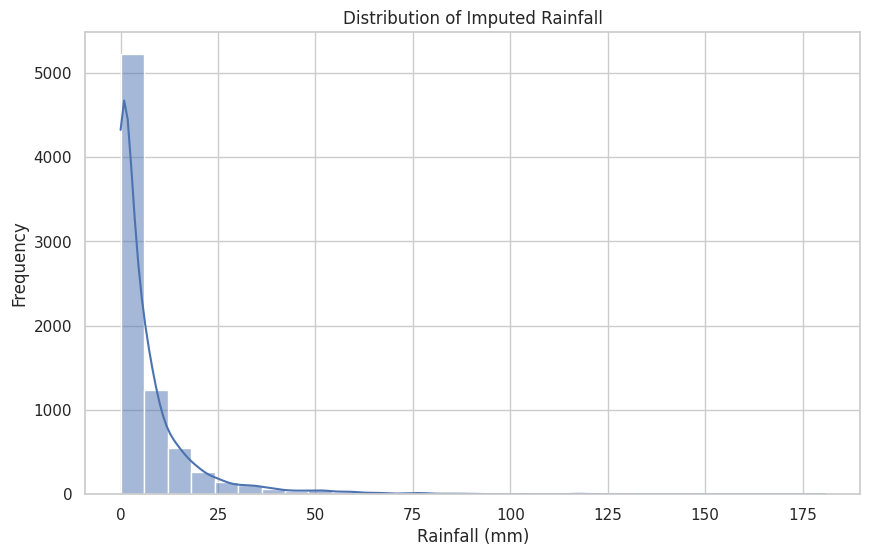

,Year,Month,Day,RH_AVG_preprocessed
count,7784.000000,7784.000000,7784.000000,7784.000000
mean,2014.999229,6.449512,15.701439,79.761305
std,5.931815,3.440696,8.797770,9.412431
min,2005.000000,1.000000,1.000000,44.000000
25%,2010.000000,3.000000,8.000000,74.000000
50%,2015.000000,6.000000,16.000000,81.000000
75%,2020.000000,9.000000,23.000000,87.000000
max,2025.000000,12.000000,31.000000,100.000000


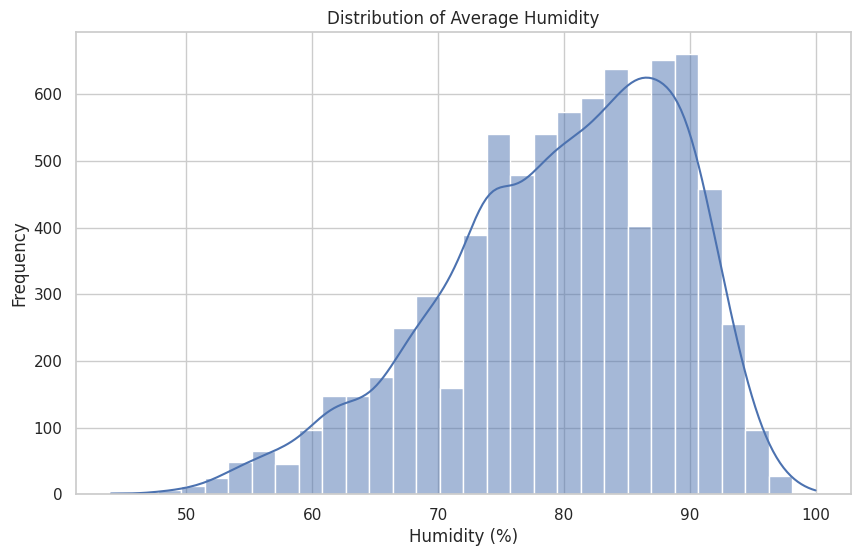

,Year,Month,Day,TN,TX,TAVG
count,7784.000000,7784.000000,7784.000000,7784.000000,7784.000000,7776.000000
mean,2014.999229,6.449512,15.701439,22.867115,32.724672,27.739120
std,5.931815,3.440696,8.797770,1.312372,1.682303,1.660285
min,2005.000000,1.000000,1.000000,13.000000,24.800000,23.300000
25%,2010.000000,3.000000,8.000000,22.200000,31.700000,26.500000
50%,2015.000000,6.000000,16.000000,23.000000,32.800000,27.600000
75%,2020.000000,9.000000,23.000000,23.600000,33.800000,28.900000
max,2025.000000,12.000000,31.000000,28.600000,37.600000,32.900000


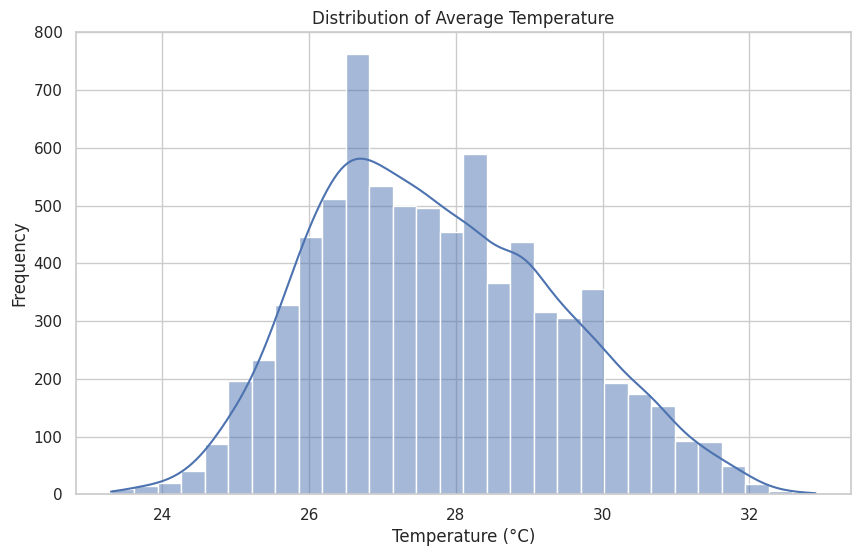

In [4]:
# Summary statistics for rainfall data
display(rainfall_data.describe())  # Display summary statistics for numerical columns
sns.histplot(rainfall_data['RR_imputed'], kde=True, bins=30)  # Plot distribution of imputed rainfall
plt.title("Distribution of Imputed Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

# Summary statistics for humidity data
display(humidity_data.describe())  # Display summary statistics for numerical columns
sns.histplot(humidity_data['RH_AVG_preprocessed'], kde=True, bins=30)  # Plot distribution of average humidity
plt.title("Distribution of Average Humidity")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.show()

# Summary statistics for temperature data
display(temperature_data.describe())  # Display summary statistics for numerical columns
sns.histplot(temperature_data['TAVG'], kde=True, bins=30)  # Plot distribution of average temperature
plt.title("Distribution of Average Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

# Merge the Datasets
Combine the three datasets into a single DataFrame using the Date column as the key for merging.

In [5]:
# Merge the Datasets
# Merge the rainfall and humidity datasets on the Date column
rainfall_humidity_merged = pd.merge(rainfall_data, humidity_data, on="Date", how="inner")

# Merge the resulting DataFrame with the temperature dataset on the Date column
weather_data = pd.merge(rainfall_humidity_merged, temperature_data, on="Date", how="inner")

# Display the first few rows of the merged DataFrame to verify successful merging
display(weather_data.head())

# Display summary statistics for the merged DataFrame
display(weather_data.describe())

,Date,Year_x,Month_x,Day_x,RR_original,RR_estimation_method,RR_imputed,imputation_method,is_outlier,Year_y,Month_y,Day_y,RH_AVG_preprocessed,Year,Month,Day,TN,TX,TAVG
0,2005-01-01,2005,1,1,8888.0,meteorological_estimate_with_ss,16.891522,meteorological_estimate_with_ss,False,2005,1,1,90.0,2005,1,1,21.0,33.2,25.7
1,2005-01-02,2005,1,2,8888.0,meteorological_estimate_with_ss,11.305400,meteorological_estimate_with_ss,False,2005,1,2,90.0,2005,1,2,22.0,33.0,26.3
2,2005-01-03,2005,1,3,8888.0,meteorological_estimate_with_ss,16.201168,meteorological_estimate_with_ss,False,2005,1,3,90.0,2005,1,3,21.0,33.0,26.5
3,2005-01-04,2005,1,4,2.0,NaN,2.000000,NaN,False,2005,1,4,89.0,2005,1,4,22.0,33.0,26.5
4,2005-01-05,2005,1,5,8888.0,meteorological_estimate_with_ss,4.143532,meteorological_estimate_with_ss,False,2005,1,5,88.0,2005,1,5,21.0,32.8,25.6


,Year_x,Month_x,Day_x,RR_original,RR_imputed,Year_y,Month_y,Day_y,RH_AVG_preprocessed,Year,Month,Day,TN,TX,TAVG
count,9650.000000,9650.000000,9650.000000,8503.000000,9650.000000,9650.000000,9650.000000,9650.000000,9650.000000,9650.000000,9650.000000,9650.000000,9650.000000,9650.000000,9642.000000
mean,2016.150881,6.450259,15.622383,2277.315677,7.146336,2016.150881,6.450259,15.622383,78.858653,2016.150881,6.450259,15.622383,22.921513,32.649445,27.906347
std,5.828537,3.403385,8.801398,3873.488480,12.471304,5.828537,3.403385,8.801398,9.433419,5.828537,3.403385,8.801398,1.240746,1.658004,1.656221
min,2005.000000,1.000000,1.000000,0.000000,0.000000,2005.000000,1.000000,1.000000,44.000000,2005.000000,1.000000,1.000000,13.000000,24.800000,23.300000
25%,2011.000000,4.000000,8.000000,0.100000,0.103015,2011.000000,4.000000,8.000000,73.000000,2011.000000,4.000000,8.000000,22.400000,31.600000,26.600000
50%,2018.000000,6.000000,15.000000,6.000000,2.853249,2018.000000,6.000000,15.000000,80.000000,2018.000000,6.000000,15.000000,23.000000,32.800000,27.800000
75%,2021.000000,9.000000,23.000000,8888.000000,8.100000,2021.000000,9.000000,23.000000,86.000000,2021.000000,9.000000,23.000000,23.600000,33.800000,29.100000
max,2025.000000,12.000000,31.000000,8888.000000,180.800000,2025.000000,12.000000,31.000000,100.000000,2025.000000,12.000000,31.000000,28.600000,37.600000,32.900000


# Analyze Missing Values and Imputations
Analyze the imputation methods used in the rainfall data, including meteorological estimations and identify patterns in how missing values were handled.

/tmp/ipykernel_19109/1345875209.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imputation_method_counts.index, y=imputation_method_counts.values, palette="viridis")


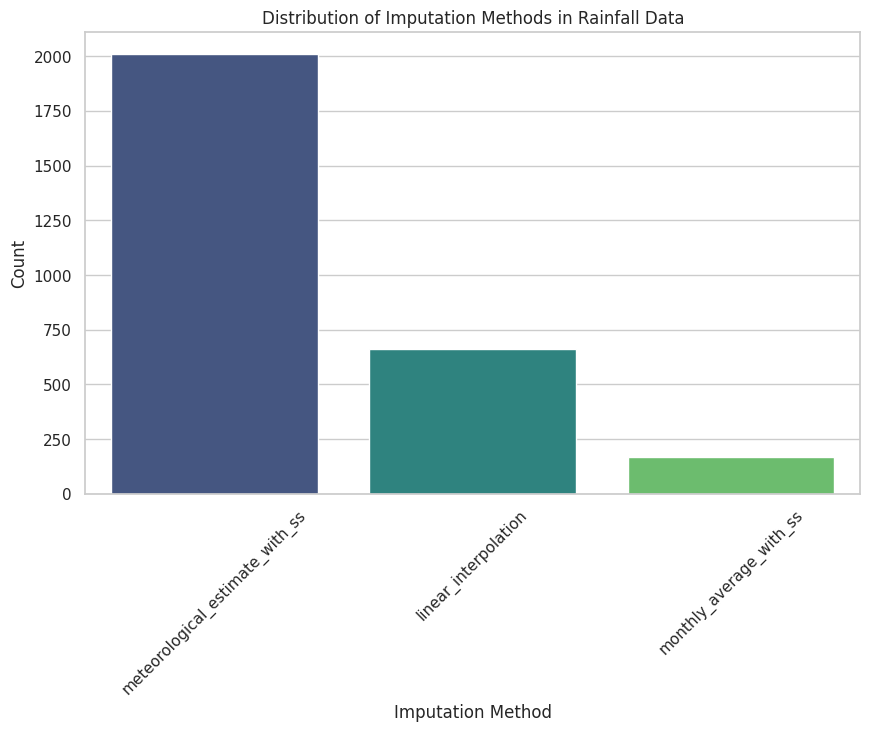

/tmp/ipykernel_19109/1345875209.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rainfall_data, x='imputation_method', y='RR_imputed', palette="coolwarm")


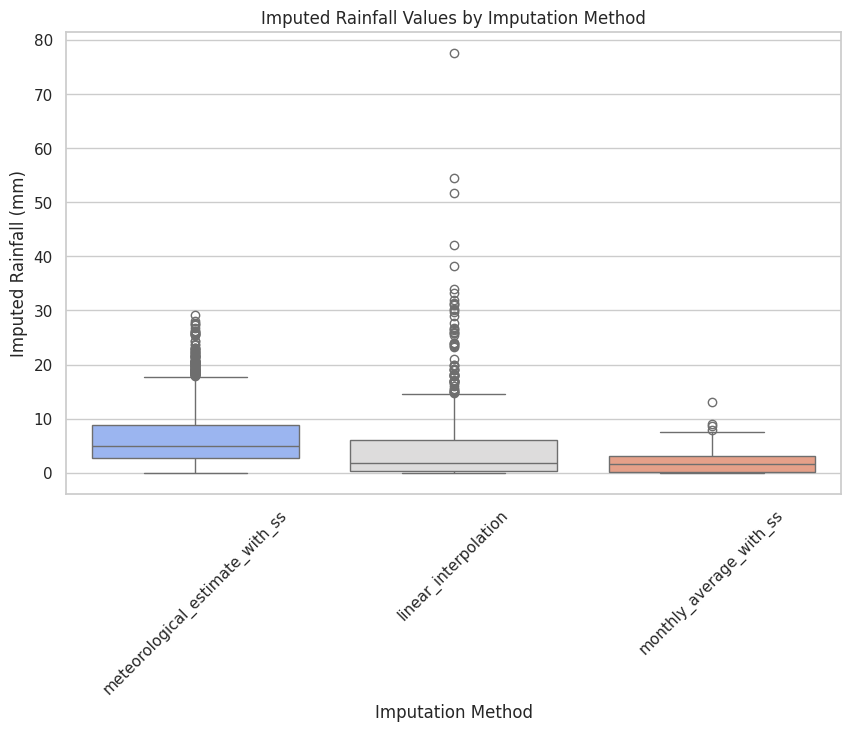

Number of missing values in original rainfall data: 829


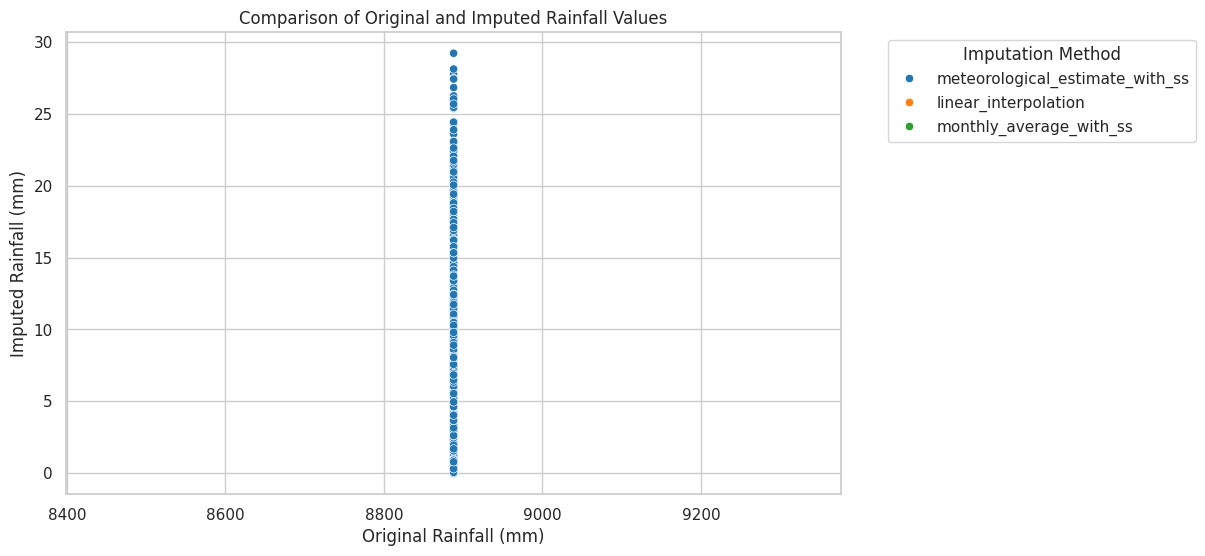

In [6]:
# Analyze Missing Values and Imputations

# Analyze the distribution of imputation methods in the rainfall data
imputation_method_counts = rainfall_data['imputation_method'].value_counts()

# Plot the distribution of imputation methods
sns.barplot(x=imputation_method_counts.index, y=imputation_method_counts.values, palette="viridis")
plt.title("Distribution of Imputation Methods in Rainfall Data")
plt.xlabel("Imputation Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Analyze the relationship between imputed rainfall values and the imputation methods
sns.boxplot(data=rainfall_data, x='imputation_method', y='RR_imputed', palette="coolwarm")
plt.title("Imputed Rainfall Values by Imputation Method")
plt.xlabel("Imputation Method")
plt.ylabel("Imputed Rainfall (mm)")
plt.xticks(rotation=45)
plt.show()

# Identify patterns in missing values and imputations
missing_values_count = rainfall_data['RR_original'].isna().sum()
print(f"Number of missing values in original rainfall data: {missing_values_count}")

# Compare original and imputed rainfall values for non-outlier data
non_outlier_data = rainfall_data[rainfall_data['is_outlier'] == False]
sns.scatterplot(data=non_outlier_data, x='RR_original', y='RR_imputed', hue='imputation_method', palette="tab10")
plt.title("Comparison of Original and Imputed Rainfall Values")
plt.xlabel("Original Rainfall (mm)")
plt.ylabel("Imputed Rainfall (mm)")
plt.legend(title="Imputation Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Visualize Weather Patterns
Create visualizations to explore seasonal patterns and relationships between rainfall, humidity, and temperature over time.

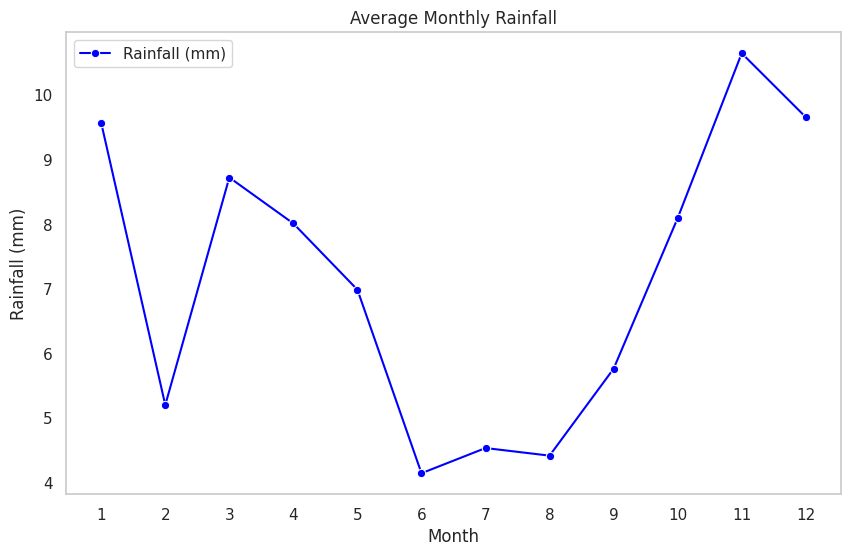

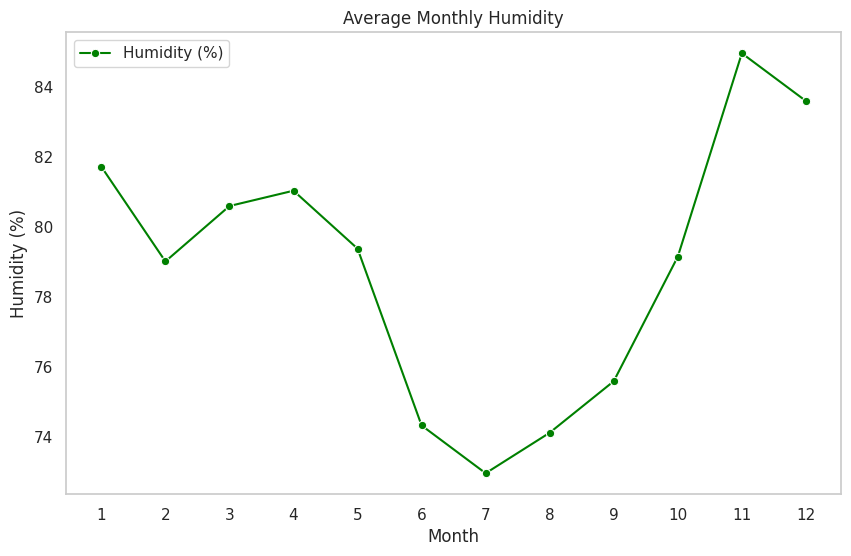

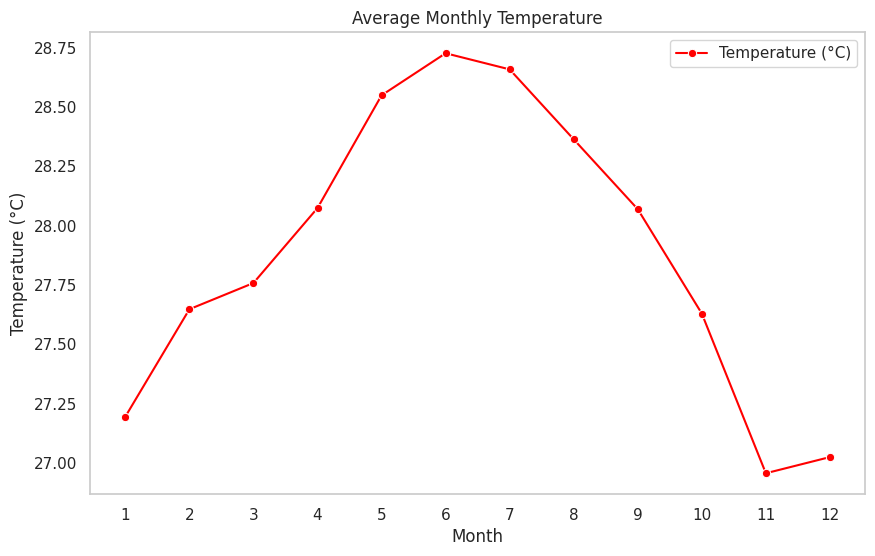

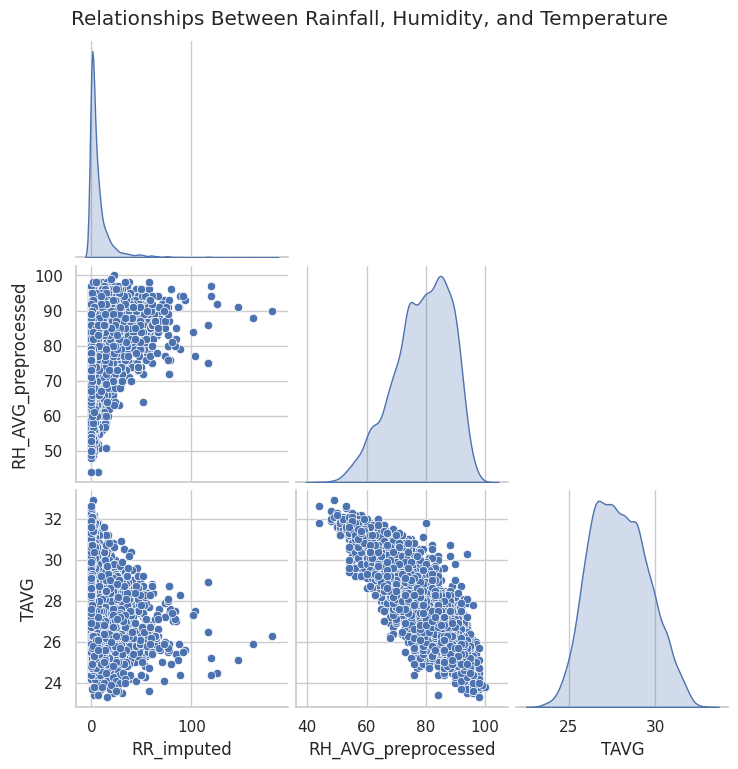

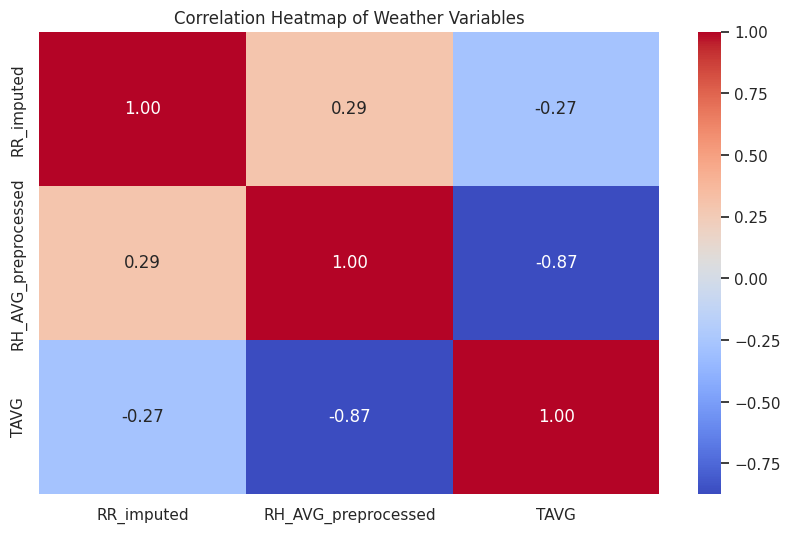

In [7]:
# Visualize Weather Patterns

# Plot seasonal patterns of rainfall, humidity, and temperature
weather_data['Month'] = pd.to_datetime(weather_data['Date']).dt.month  # Extract month from Date

# Average rainfall, humidity, and temperature by month
monthly_avg = weather_data.groupby('Month').agg({
    'RR_imputed': 'mean',
    'RH_AVG_preprocessed': 'mean',
    'TAVG': 'mean'
}).reset_index()

# Plot average rainfall by month
sns.lineplot(data=monthly_avg, x='Month', y='RR_imputed', marker='o', label='Rainfall (mm)', color='blue')
plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

# Plot average humidity by month
sns.lineplot(data=monthly_avg, x='Month', y='RH_AVG_preprocessed', marker='o', label='Humidity (%)', color='green')
plt.title("Average Monthly Humidity")
plt.xlabel("Month")
plt.ylabel("Humidity (%)")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

# Plot average temperature by month
sns.lineplot(data=monthly_avg, x='Month', y='TAVG', marker='o', label='Temperature (°C)', color='red')
plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

# Explore relationships between rainfall, humidity, and temperature
sns.pairplot(weather_data, vars=['RR_imputed', 'RH_AVG_preprocessed', 'TAVG'], diag_kind='kde', corner=True)
plt.suptitle("Relationships Between Rainfall, Humidity, and Temperature", y=1.02)
plt.show()

# Correlation heatmap
correlation_matrix = weather_data[['RR_imputed', 'RH_AVG_preprocessed', 'TAVG']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Weather Variables")
plt.show()

# Correlation Analysis
Calculate and visualize correlations between different weather parameters such as rainfall, humidity, and temperature variables.

Correlation Matrix:
                     RR_imputed  RH_AVG_preprocessed      TAVG
RR_imputed             1.000000             0.290883 -0.272494
RH_AVG_preprocessed    0.290883             1.000000 -0.872061
TAVG                  -0.272494            -0.872061  1.000000


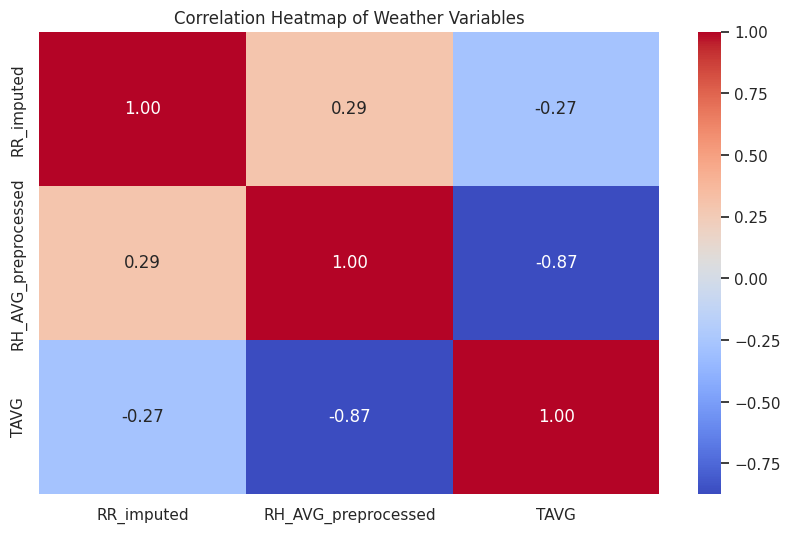

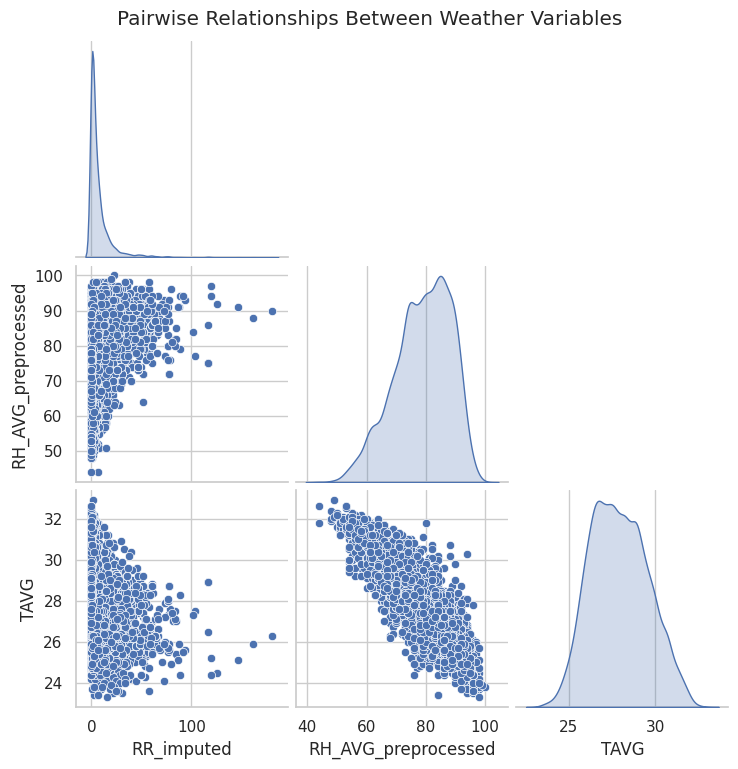

In [8]:
# Calculate the correlation matrix for the selected weather variables
correlation_matrix = weather_data[['RR_imputed', 'RH_AVG_preprocessed', 'TAVG']].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Weather Variables")
plt.show()

# Pairplot to visualize pairwise relationships between variables
sns.pairplot(weather_data, vars=['RR_imputed', 'RH_AVG_preprocessed', 'TAVG'], diag_kind='kde', corner=True)
plt.suptitle("Pairwise Relationships Between Weather Variables", y=1.02)
plt.show()

# Time Series Analysis
Perform time series analysis to identify trends, seasonality, and potential anomalies in the weather data.

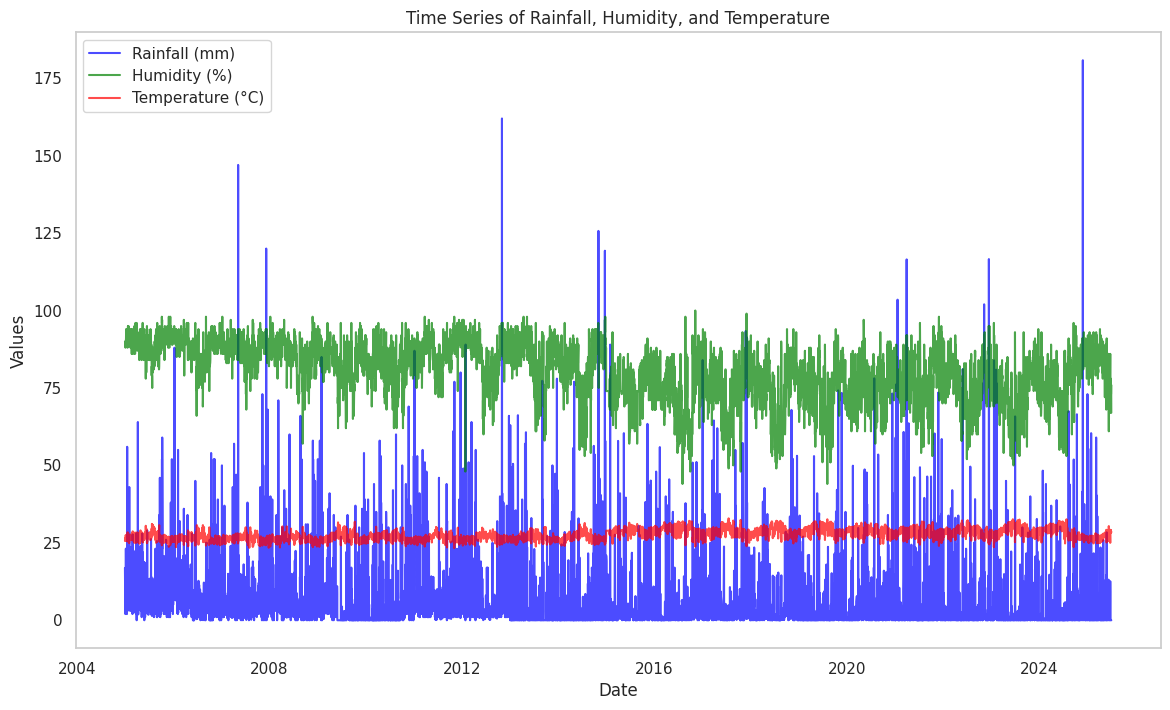

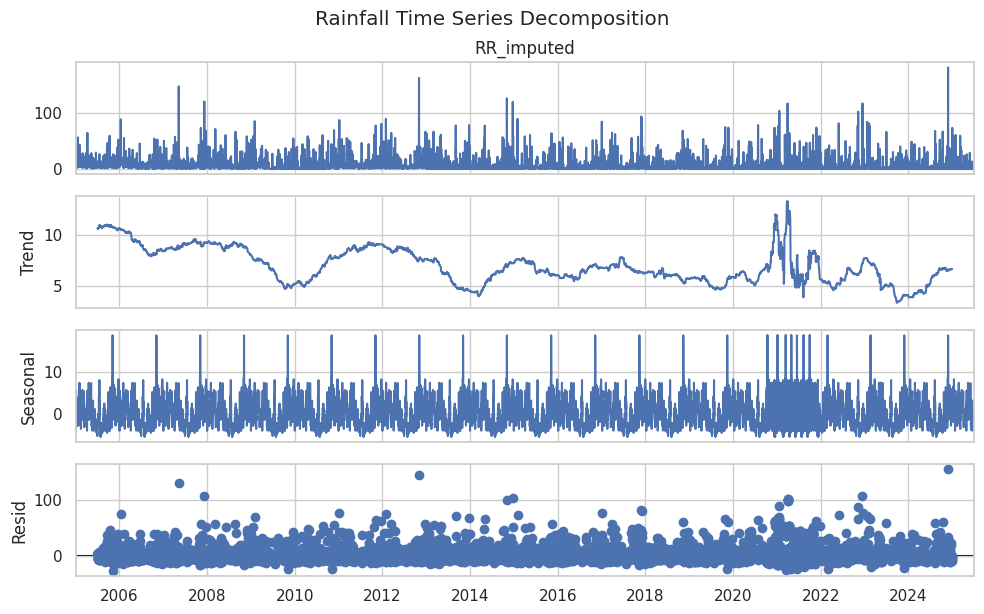

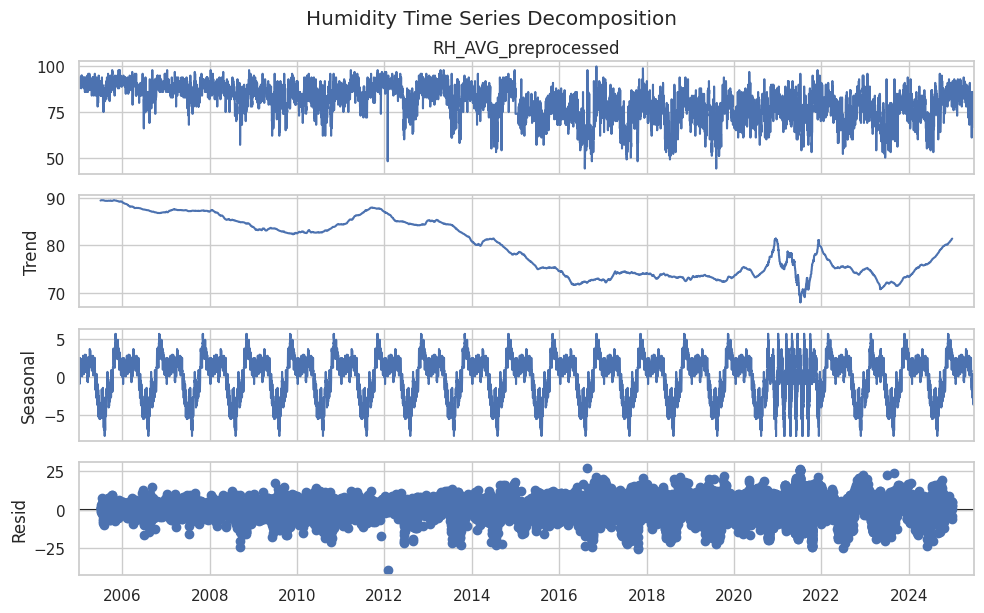

ValueError: This function does not handle missing values

In [9]:
# Perform time series analysis to identify trends, seasonality, and potential anomalies in the weather data

# Convert the Date column to datetime format for time series analysis
weather_data['Date'] = pd.to_datetime(weather_data['Date'])

# Set the Date column as the index for time series analysis
weather_data.set_index('Date', inplace=True)

# Plot the time series of rainfall, humidity, and temperature
plt.figure(figsize=(14, 8))
plt.plot(weather_data.index, weather_data['RR_imputed'], label='Rainfall (mm)', color='blue', alpha=0.7)
plt.plot(weather_data.index, weather_data['RH_AVG_preprocessed'], label='Humidity (%)', color='green', alpha=0.7)
plt.plot(weather_data.index, weather_data['TAVG'], label='Temperature (°C)', color='red', alpha=0.7)
plt.title("Time Series of Rainfall, Humidity, and Temperature")
plt.xlabel("Date")
plt.ylabel("Values")
plt.legend()
plt.grid()
plt.show()

# Decompose the time series of rainfall into trend, seasonality, and residuals
from statsmodels.tsa.seasonal import seasonal_decompose

rainfall_decomposition = seasonal_decompose(weather_data['RR_imputed'], model='additive', period=365)
rainfall_decomposition.plot()
plt.suptitle("Rainfall Time Series Decomposition", y=1.02)
plt.show()

# Decompose the time series of humidity into trend, seasonality, and residuals
humidity_decomposition = seasonal_decompose(weather_data['RH_AVG_preprocessed'], model='additive', period=365)
humidity_decomposition.plot()
plt.suptitle("Humidity Time Series Decomposition", y=1.02)
plt.show()

# Decompose the time series of temperature into trend, seasonality, and residuals
temperature_decomposition = seasonal_decompose(weather_data['TAVG'], model='additive', period=365)
temperature_decomposition.plot()
plt.suptitle("Temperature Time Series Decomposition", y=1.02)
plt.show()

# Detect anomalies in rainfall using a rolling mean and standard deviation
rolling_mean = weather_data['RR_imputed'].rolling(window=30).mean()
rolling_std = weather_data['RR_imputed'].rolling(window=30).std()

plt.figure(figsize=(14, 8))
plt.plot(weather_data.index, weather_data['RR_imputed'], label='Rainfall (mm)', color='blue', alpha=0.7)
plt.plot(weather_data.index, rolling_mean, label='Rolling Mean (30 days)', color='orange', linestyle='--')
plt.fill_between(weather_data.index, rolling_mean - 2 * rolling_std, rolling_mean + 2 * rolling_std, color='gray', alpha=0.3, label='Confidence Interval (2 std)')
plt.title("Rainfall Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid()
plt.show()

# Highlight potential anomalies in rainfall
anomalies = weather_data[(weather_data['RR_imputed'] > rolling_mean + 2 * rolling_std) | (weather_data['RR_imputed'] < rolling_mean - 2 * rolling_std)]
print(f"Number of anomalies detected in rainfall: {len(anomalies)}")
display(anomalies)